<a href="https://colab.research.google.com/github/NiteshJ98/LLM-from-scratch/blob/main/Autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Autograd:***

Autograd is the engine that makes neural network training possible. Once you truly understand this, the entire training loop becomes obvious rather than magical. Let's build the intuition from scratch.

*The problem autograd solves*

Training a neural network means adjusting weights to reduce loss. To do that you need to know: for each weight, if I nudge it slightly, does the loss go up or down, and by how much? That's a derivative — specifically, ∂loss/∂weight for every single weight.

A large model has billions of weights. Computing each derivative by hand is impossible. Autograd does it automatically, for all of them, in one backward pass.

***How it works — the computation graph***

Every time you do an operation on a tensor that has *requires_grad=True*, PyTorch silently builds a graph recording what happened. Each node in the graph is an operation. Each edge is a tensor flowing through it. When you call* .backward()*, PyTorch walks this graph in reverse, applying the chain rule at each node to accumulate gradients.

**Forward Pass**

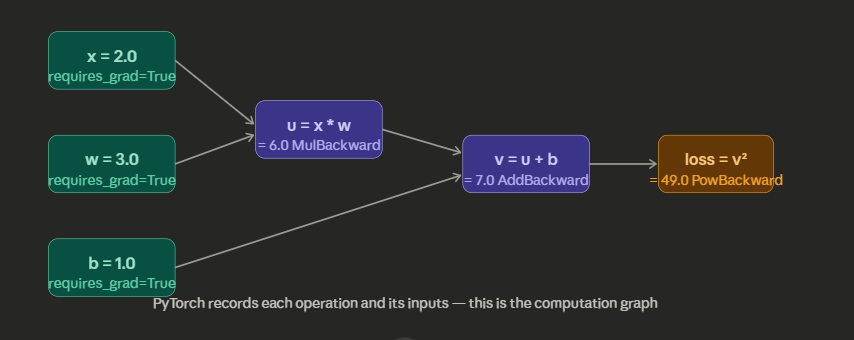

**Backward Pass**

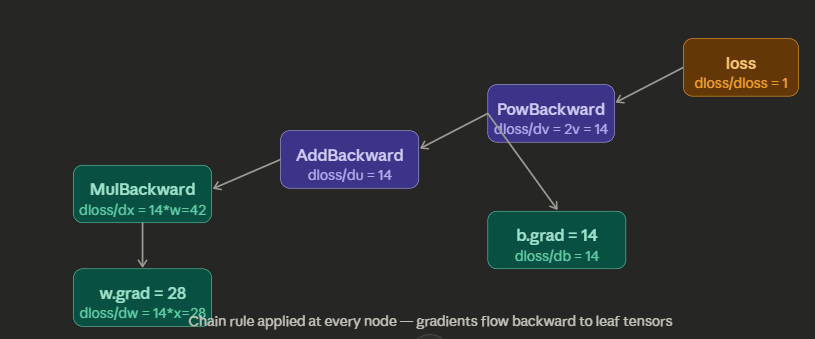

**Full Graph**

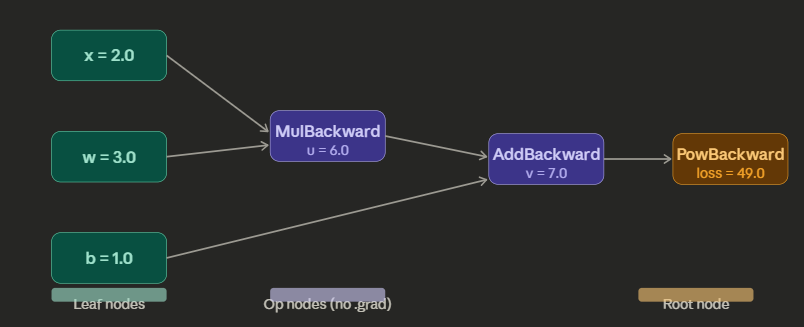

The forward builds the graph, backward walks it in reverse applying the chain rule, and the full graph view shows the complete picture.

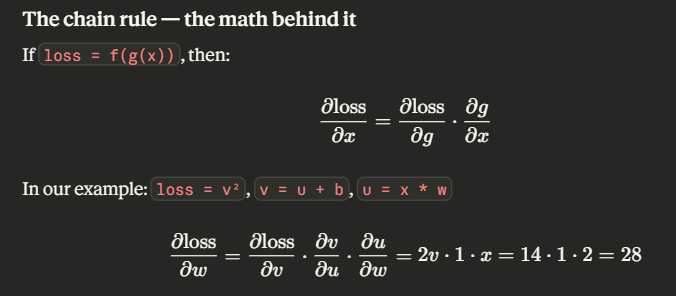

In [27]:
import torch

# --- Part 1: Basic autograd ---

# requires_grad=True tells PyTorch: track operations on this tensor
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# Forward pass — PyTorch silently builds the computation graph
u    = x * w        # u = 6.0
v    = u + b        # v = 7.0
loss = v ** 2       # loss = 49.0

print(f"loss = {loss.item()}")   # 49.0

# Each tensor knows its creator operation
print(loss.grad_fn)   # <PowBackward0>
print(v.grad_fn)      # <AddBackward0>
print(u.grad_fn)      # <MulBackward0>
print(x.grad_fn)      # None — x is a leaf, it has no creator
print(w.grad_fn)      # None — w is a leaf, it has no creator, same for b

# Backward pass — walks the graph, applies chain rule at each node
loss.backward()

# Gradients are now stored in .grad on leaf tensors
print(f"x.grad = {x.grad}")   # 28.0  (dloss/dx = 2v * w = 14 * 3 = 42... wait)
print(f"w.grad = {w.grad}")   # 28.0  (dloss/dw = 2v * x = 14 * 2 = 28)
print(f"b.grad = {b.grad}")   # 14.0  (dloss/db = 2v * 1 = 14)

loss = 49.0
None
None
x.grad = 42.0
w.grad = 28.0
b.grad = 14.0


When loss.item() is 49.0, it means the scalar value of your loss tensor is 49.0. Now, loss.backward() initiates the backward pass of the autograd system. Here's what it does:

1. **Calculates Gradients:** It computes the gradients of the loss (which is 49.0) with respect to all the leaf tensors that have requires_grad=True in the computation graph that led to this loss. In your example, these leaf tensors are x, w, and b.
2. **Applies the Chain Rule:** It traverses the computation graph from the loss tensor backward to the leaf tensors, applying the chain rule at each operation node to determine how much each parameter contributes to the total loss.
3. **Stores Gradients:** The computed gradients are then accumulated in the .grad attribute of these leaf tensors (x.grad, w.grad, b.grad). These .grad attributes will then contain d(loss)/d(x), d(loss)/d(w), and d(loss)/d(b) respectively.

It's important to remember that loss.backward() does not return any value; its purpose is to populate the .grad attributes of the tensors involved in the computation.

In [7]:
# Manual verification using the chain rule
v_val   = (x * w + b).item()   # 7.0
dloss_dv = 2 * v_val            # 14.0  (d/dv of v^2)
dv_du    = 1.0                  # d/du of (u + b)
du_dw    = x.item()             # 2.0   (d/dw of x*w)
du_dx    = w.item()             # 3.0   (d/dx of x*w)

print(f"dloss/dw (manual) = {dloss_dv * dv_du * du_dw}")  # 28.0 ✓
print(f"dloss/dx (manual) = {dloss_dv * dv_du * du_dx}")  # 42.0
print(f"dloss/db (manual) = {dloss_dv * 1.0}")            # 14.0 ✓

# x.grad should be 42, not 28 — let's re-check
x2 = torch.tensor(2.0, requires_grad=True)
w2 = torch.tensor(3.0, requires_grad=True)
b2 = torch.tensor(1.0, requires_grad=True)
loss2 = (x2 * w2 + b2) ** 2
loss2.backward()
print(f"x.grad = {x2.grad}")   # 42.0 ✓

dloss/dw (manual) = 28.0
dloss/dx (manual) = 42.0
dloss/db (manual) = 14.0
x.grad = 42.0


The critical detail — gradient accumulation
This is where almost every beginner gets burned. PyTorch adds gradients to .grad rather than replacing them. If you call *.backward()* twice without clearing, gradients stack up.

In [8]:
w = torch.tensor(3.0, requires_grad=True)

# First forward + backward
loss1 = (w * 2) ** 2    # loss = 36, dloss/dw = 2*(2w)*2 = 24
loss1.backward()
print(f"After 1st backward: w.grad = {w.grad}")   # 24.0

# Second forward + backward — WITHOUT zeroing grad
loss2 = (w * 2) ** 2
loss2.backward()
print(f"After 2nd backward: w.grad = {w.grad}")   # 48.0 — ACCUMULATED, not 24!

# Correct pattern — zero before each backward
w.grad.zero_()
loss3 = (w * 2) ** 2
loss3.backward()
print(f"After zero + backward: w.grad = {w.grad}")  # 24.0 ✓

After 1st backward: w.grad = 24.0
After 2nd backward: w.grad = 48.0
After zero + backward: w.grad = 24.0


This is why the training loop always has *optimizer.zero_grad()* at the start. It calls *.zero_()* on every parameter's *.grad*. Skip it and your gradients are wrong every step after the first.


**The full training loop — autograd in action**
```
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
```


This line initializes an optimizer for your neural network model. Let's break down its components:

**optimizer** = torch.optim.SGD(...): This creates an optimizer object using Stochastic Gradient Descent (SGD), which is a common algorithm used to update the weights and biases of a neural network during training. The optimizer's job is to adjust the model's parameters in the direction that minimizes the loss function.

**model.parameters()**: This method is called on your model (which is an nn.Linear instance in your code). It returns an iterator over all the learnable parameters (weights and biases) of the model. These are the tensors that SGD will update.

**lr=0.01**: This stands for 'learning rate'. It's a
crucial hyperparameter that determines the step size at each iteration while moving toward a minimum of the loss function. A learning rate of 0.01 means that the optimizer will adjust the parameters by 1% of the calculated gradient in each step.

In [21]:
import torch
import torch.nn as nn

# Toy dataset: y = 2x + 1
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
print(X.shape)
y = torch.tensor([[3.0], [5.0], [7.0], [9.0]])

# One linear layer — weight and bias are leaf tensors with requires_grad=True
model     = nn.Linear(1, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn   = nn.MSELoss()

for step in range(100):
    # 1. Zero gradients — MUST do this every step
    optimizer.zero_grad()

    # 2. Forward pass — builds the computation graph
    pred = model(X)

    # 3. Compute loss
    loss = loss_fn(pred, y)

    # 4. Backward pass — walks graph, fills .grad on all parameters
    loss.backward()

    # 5. Optimizer step — uses .grad to update weights
    optimizer.step()

    if step % 20 == 0:
        print(f"Step {step:3d} | loss = {loss.item():.4f} | "
              f"w = {model.weight.item():.3f} | "
              f"b = {model.bias.item():.3f}")

print(f"\nLearned: y = {model.weight.item():.2f}x + {model.bias.item():.2f}")
print(f"Target:  y = 2.00x + 1.00")

torch.Size([4, 1])
Step   0 | loss = 22.1241 | w = 0.770 | b = 0.407
Step  20 | loss = 0.0185 | w = 2.017 | b = 0.841
Step  40 | loss = 0.0033 | w = 2.046 | b = 0.861
Step  60 | loss = 0.0029 | w = 2.045 | b = 0.869
Step  80 | loss = 0.0026 | w = 2.042 | b = 0.877

Learned: y = 2.04x + 0.88
Target:  y = 2.00x + 1.00


In [22]:
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
y = x * w + 1

# Every non-leaf tensor has a grad_fn with .next_functions
# pointing to the ops that created its inputs
print(y.grad_fn)                        # AddBackward0
print(y.grad_fn.next_functions)         # ((MulBackward0, 0), (AccumulateGrad, 0))
print(y.grad_fn.next_functions[0][0])   # MulBackward0
print(y.grad_fn.next_functions[0][0].next_functions)  # x and w's AccumulateGrad nodes

# is_leaf — True only for tensors created directly, not by operations
print(x.is_leaf)    # True
print(y.is_leaf)    # False

# Only leaf tensors get .grad populated after backward
# Intermediate tensors' gradients are discarded (saves memory)
# To keep them for inspection:
y.retain_grad()
loss = y ** 2
loss.backward()
print(f"y.grad = {y.grad}")   # 2*y = 2*7 = 14
print(f"x.grad = {x.grad}")   # 14 * w = 14 * 3 = 42

((<MulBackward0 object at 0x78155d8a1810>, 0), (None, 0))
((<AccumulateGrad object at 0x78155f2ae0b0>, 0), (<AccumulateGrad object at 0x78155bbdbe20>, 0))
True
False
y.grad = 14.0
x.grad = 42.0


**Detaching from the graph**

Sometimes you want a tensor's value but don't want gradients flowing through it — for instance when computing a metric, doing inference, or feeding a tensor into a separate computation.

In [23]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 3   # y = 8.0, tracked

# .detach() returns a new tensor with same data, no grad tracking
y_detached = y.detach()
print(y_detached.requires_grad)   # False

# torch.no_grad() — block graph building for a whole block
# Use this for inference — faster and saves memory
with torch.no_grad():
    z = x ** 3
    print(z.requires_grad)   # False

# .item() — pulls a scalar out as a plain Python float
# Commonly used for printing loss without keeping the graph alive
loss = (x * 2) ** 2
print(loss.item())    # 16.0 — plain float, no graph attached

False
False
16.0


In a training loop you always call *loss.item()* when logging — not *loss* directly — because holding a reference to the loss tensor keeps the entire computation graph alive in memory.

**The five-line mental model**
Every time you see a training loop, map it to these five things:



```
optimizer.zero_grad()   # clear accumulated gradients from last step
pred  = model(X)        # forward pass — builds computation graph
loss  = loss_fn(pred,y) # compute scalar loss at the root of graph
loss.backward()         # reverse traversal — fills .grad everywhere
optimizer.step()        # w = w - lr * w.grad  for every parameter
```

